# Quickstart
The following notebook introduces `iconspy`'s datatypes and some of their associated methods.

Having followed through this tutorial you will be able to construct and visusalise `iconspy` sections.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import xarray as xr
import iconspy as ispy
import cmocean.cm as cmo

## Load and prepare the example data

We will load from netcdf files as `tgrid` which describes the model grid, and an `fxgrid` which contains bathymetry information.

We then have to put them in a format that `iconspy` can understand. For the `tgrid` this means calling `ispy.convert_tgrid_data`, and for the the `fxgrid` we must make sure the dimensions have the correct names.

In [ ]:
ocean_tgrid_path = Path("/pool/data/ICON/oes/input/r0005/OceanOnly_icon_grid_0023_R02B07_G_modified_srtm30_1min/R2B7_ocean-grid.nc")
ocean_fxgrid_path = Path("/pool/data/ICON/oes/input/r0005/OceanOnly_icon_grid_0023_R02B07_G_modified_srtm30_1min/L72/R2B7L72_fx.nc")

ds_tgrid = xr.open_dataset(ocean_tgrid_path)  # horizontal grid information
ds_fx = xr.open_dataset(ocean_fxgrid_path)  # Contains bathymetry etc.

# Put datasets into the iconspy format
ds_IsD = ispy.convert_tgrid_data(ds_tgrid)

ds_fx = ds_fx.rename(
    {
        "ncells": "cell",
        "ncells_2": "edge",
        "ncells_3": "vertex",
    }
)

In [2]:
def setup_plot_area(ds_IsD):
    Slat, Nlat = -25, 5
    Wlon, Elon = -95, -65

    edges_in_region = ds_IsD["edge"].where(
        (ds_IsD["elon"] > Wlon) * (ds_IsD["elon"] < Elon) * (ds_IsD["elat"] > Slat) * (ds_IsD["elat"] < Nlat)
        , drop=True).astype("int32")


    lons = ds_IsD["vlon"].sel(vertex=ds_IsD["edge_vertices"])
    lats = ds_IsD["vlat"].sel(vertex=ds_IsD["edge_vertices"])

    fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()})

    # for edge in edges_in_region:
    #     ax.plot(
    #         lons.isel(edge=edge),
    #         lats.isel(edge=edge),
    #         color="black",
    #         alpha=0.2,
    #     )

    # ax.scatter(
    #     ds_IsD["vlon"],
    #     ds_IsD["vlat"],
    #     s=4,
    #     transform=ccrs.PlateCarree(),
    #     color="tab:green"
    # )

    ax.set_xlim(Wlon, Elon)
    ax.set_ylim(Slat, Nlat)
    ax.set_aspect("equal")

    ax.coastlines()
    ax.grid(False)
    return fig, ax

(<Figure size 640x480 with 1 Axes>, <GeoAxes: >)

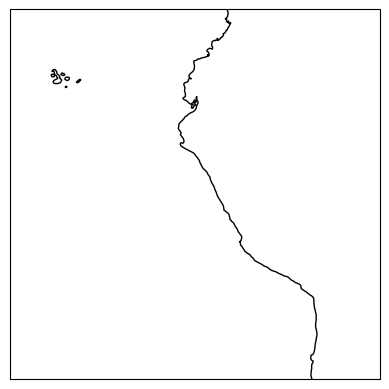

In [8]:
setup_plot_area(ds_IsD)

## Define the stations we want to connect
To define a section we need two or more points to connect. Typically we have a rough idea of where we want these points to be, and we would like to choose the model grid points closest to these coordinates. Sometimes we have a desire for one of the points to be on land.

In the below we will define a section near Fram Strait, stretching from a point on Greenland to a point offshore.

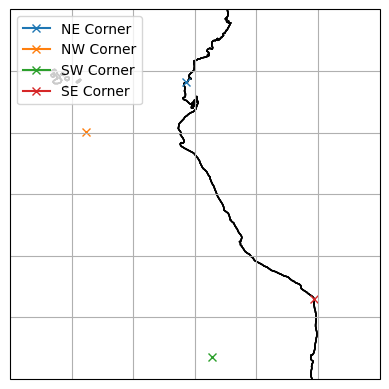

In [4]:
# Put in the approximate coordinates of the points we want
# Specify that we want the George Town point to be on the boundary
target_ne_corner = ispy.TargetStation("NE Corner", -80.72, -0.928, boundary=True)
target_nw_corner = ispy.TargetStation("NW Corner", -88.794, -4.976, boundary=False)
target_sw_corner = ispy.TargetStation("SW Corner", -78.592, -23.219, boundary=False)
target_se_corner = ispy.TargetStation("SE Corner", -70.285, -18.491, boundary=True)

# Visualise the points
fig, ax = setup_plot_area(ds_IsD)
target_ne_corner.plot(ax=ax, gridlines=False)
target_nw_corner.plot(ax=ax, gridlines=False)
target_sw_corner.plot(ax=ax, gridlines=False)
target_se_corner.plot(ax=ax, gridlines=False)
gl = ax.gridlines()
# gl.xlines, gl.ylines = False, False
# ax.grid(visible=False)
ax.legend(loc=2)

The map shows the approximate location of the points we want to join. We can now find the model grid points nearest to them and plot them.

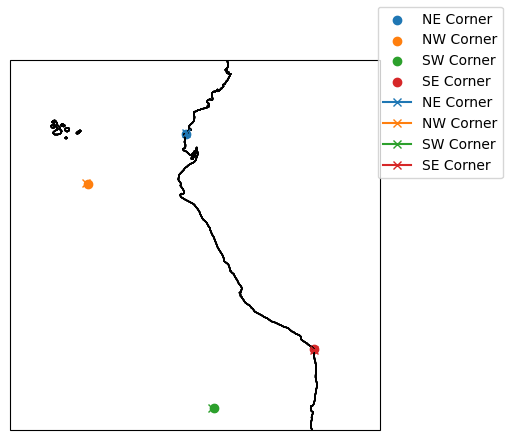

In [12]:
# Convert the target stations to model stations
model_ne_corner = target_ne_corner.to_model_station(ds_IsD)
model_nw_corner = target_nw_corner.to_model_station(ds_IsD)
model_sw_corner = target_sw_corner.to_model_station(ds_IsD)
model_se_corner = target_se_corner.to_model_station(ds_IsD)

fig, ax = setup_plot_area(ds_IsD)

# Plot the model stations (circles)
model_ne_corner.plot(ax=ax, gridlines=False)
model_nw_corner.plot(ax=ax, gridlines=False)
model_sw_corner.plot(ax=ax, gridlines=False)
model_se_corner.plot(ax=ax, gridlines=False)

# Compare with the target station (crosses)
target_ne_corner.plot(ax=ax, gridlines=False)
target_nw_corner.plot(ax=ax, gridlines=False)
target_sw_corner.plot(ax=ax, gridlines=False)
target_se_corner.plot(ax=ax, gridlines=False)

fig.legend()

## Connect stations to form sections

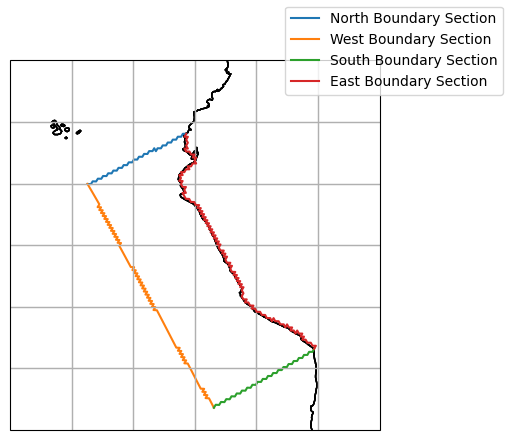

In [18]:
north_boundary_section = ispy.Section(
    "North Boundary Section",
    model_ne_corner,
    model_nw_corner,
    ds_IsD,
    section_type="great circle"
)

west_boundary_section = ispy.Section(
    "West Boundary Section",
    model_nw_corner,
    model_sw_corner,
    ds_IsD,
    section_type="great circle"
)

south_boundary_section = ispy.Section(
    "South Boundary Section",
    model_sw_corner,
    model_se_corner,
    ds_IsD,
    section_type="great circle"
)

east_boundary_section = ispy.LandSection(
    "East Boundary Section",
    model_se_corner,
    model_ne_corner,
    ds_IsD,
    section_type="shortest"
)

fig, ax = setup_plot_area(ds_IsD)
north_boundary_section.plot(ax=ax)
west_boundary_section.plot(ax=ax)
south_boundary_section.plot(ax=ax)
east_boundary_section.plot(ax=ax)

fig.legend()

# cax = ax.tripcolor(
#     ds_IsD["clon"],
#     ds_IsD["clat"],
#     ds_fx["column_thick_c"],
#     vmin=0,
#     vmax=5000,
#     cmap=cmo.deep,
# )

# fig.colorbar(cax, ax=ax, label="Column thickness")

We can get the orientation of edges along a path by running the below:

In [20]:
north_boundary_section.set_pyic_orientation_along_path(ds_IsD)
west_boundary_section.set_pyic_orientation_along_path(ds_IsD)
south_boundary_section.set_pyic_orientation_along_path(ds_IsD)
east_boundary_section.set_pyic_orientation_along_path(ds_IsD)

## Connect sections to form a region

In [21]:
peru_coastal_region = ispy.Region("Peru Coastal Region", [north_boundary_section, west_boundary_section, south_boundary_section, east_boundary_section], ds_IsD)
peru_coastal_region

/work/mh0256/m301014/iconspy/iconspy/utils.py:122: UserWarning: rename 'step_in_path_v' to 'step_in_path' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  edge_path_xr = edge_path_xr.rename(step_in_path_v="step_in_path")
/work/mh0256/m301014/iconspy/iconspy/utils.py:33: UserWarning: rename 'step_in_path_v' to 'step_in_path' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  vertex_path = vertex_path.rename(step_in_path_v="step_in_path")


Region(Peru Coastal Region, [Section(North Boundary Section, NE Corner, NW Corner, great circle), Section(West Boundary Section, NW Corner, SW Corner, great circle), Section(South Boundary Section, SW Corner, SE Corner, great circle), LandSection(East Boundary Section, SE Corner, NE Corner, shortest)])

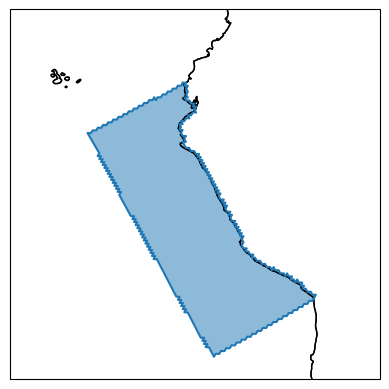

In [22]:
fig, ax = setup_plot_area(ds_IsD)
peru_coastal_region.plot(ax=ax, gridlines=False)

Regions have paths of edges and also edge orientations that we can use for calcualting fluxes into the region

In [23]:
print(peru_coastal_region.edge_circuit)
print(peru_coastal_region.path_orientation)

<xarray.DataArray 'edge' (step_in_path: 322)> Size: 1kB
array([795464, 795500, 795497, ..., 795271, 795315, 795505], dtype=int32)
Coordinates:
    step_in_path  (step_in_path) int64 3kB 1 2 3 4 5 6 ... 318 319 320 321 322
    elon          (step_in_path) float64 3kB -80.83 -80.77 ... -81.24 -81.04
    elat          (step_in_path) float64 3kB -0.9579 -1.078 ... -1.195 -1.077
    edge          (step_in_path) int32 1kB 795464 795500 ... 795315 795505
<xarray.DataArray (step_in_path: 322)> Size: 3kB
array([-1., -1.,  1.,  1.,  1., -1., -1., -1., -1.,  1., -1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1., -1., -1.,  1.,  1.,  1.,  1.,
       -1., -1., -1., -1., -1., -1., -1., -1.,  1., -1.,  1., -1., -1.,
       -1., -1., -1.,  1.,  1., -1.,  1.,  1.,  1., -1., -1.,  1.,  1.,
       -1., -1.,  1.,  1., -1., -1.,  1.,  1., -1., -1.,  1.,  1., -1.,
       -1.,  1.,  1.,  1.,  1.,  1., -1., -1.,  1.,  1.,  1.,  1.,  1.,
        1., -1., -1., -1., -1.,  1.,  1., -1., -1.,  1.,  1., -1., 

Regions also have a list of the cells contained by them

In [ ]:
peru_coastal_region.contained_cells

<xarray.DataArray 'cell' (cell: 4678)> Size: 19kB
array([508209, 508210, 508211, ..., 527761, 527762, 527763], dtype=int32)
Coordinates:
  * cell     (cell) int32 19kB 508209 508210 508211 ... 527761 527762 527763
    clon     (cell) float64 37kB -82.01 -82.0 -81.87 ... -73.62 -73.34 -73.48
    clat     (cell) float64 37kB -16.65 -16.48 -16.74 ... -17.74 -17.74 -17.99

We can also create a dataset representation of the region to be saved to a netcdf file for subsequent use.

In [33]:
muxin_out_directory = Path("/work/mh0033/")

In [34]:
peru_coastal_region.to_ispy_section(muxin_out_directory / "peru_coastal_region.nc")  # set dryrun=False to actually save the file.

Output will be saved to /work/mh0033/peru_coastal_region.nc


<xarray.Dataset> Size: 133kB
Dimensions:           (step_in_path: 322, step_in_path_v: 323, cell: 4678)
Coordinates:
  * step_in_path      (step_in_path) int64 3kB 1 2 3 4 5 ... 318 319 320 321 322
  * cell              (cell) int32 19kB 508209 508210 508211 ... 527762 527763
    elon              (step_in_path) float64 3kB -80.83 -80.77 ... -81.24 -81.04
    elat              (step_in_path) float64 3kB -0.9579 -1.078 ... -1.077
    edge              (step_in_path) int32 1kB 795464 795500 ... 795315 795505
    vlon              (step_in_path_v) float64 3kB -80.97 -80.7 ... -80.97
    vlat              (step_in_path_v) float64 3kB -0.9573 -0.9585 ... -0.9573
    vertex            (step_in_path_v) int32 1kB 269668 269663 ... 269624 269668
    clon              (cell) float64 37kB -82.01 -82.0 -81.87 ... -73.34 -73.48
    clat              (cell) float64 37kB -16.65 -16.48 -16.74 ... -17.74 -17.99
Dimensions without coordinates: step_in_path_v
Data variables:
    edge_path         (step_in_path) int32 1kB 795464 795500 ... 795315 795505
    vertex_path       (step_in_path_v) int32 1kB 269668 269663 ... 269624 269668
    path_orientation  (step_in_path) float64 3kB -1.0 -1.0 1.0 ... -1.0 1.0 1.0
    contained_cells   (cell) int32 19kB 508209 508210 508211 ... 527762 527763
Attributes:
    date:     2026-01-21 11:12:16

- the `ispy.Region` follows the logic flow as: 
    - Sections                    -> Input section list
    - calculate_section_order() 
    - order_sections()
    - calculate_vertex_circuit()  -> builds closed polygon
    - calculate_contained_cells() -> selects cells (THE MASK)
- the core function: `calculate_contained_cells()`:
    - takes the closed boundary formed by sections and returns all ICON grid cells whose **centers** lie inside that boundary
        - The closed boundary fromed by sections is done by useing `calculate_vertex_circuit()`. 
        - the `calculate_contained_cells()` take the **vertice coordinates** of the closed and ordered boundary and form into a (lon, lat) pairs -> polygon ring
        - And then convert the coordinate ring into a 2D polygon object that represents the area enclosed by my sections
        - the load the ICON cell center coordinates and test which are **inside** the polygon
            - This is because when using `cell_idxs, = np.where(enclosed_area.contains(cell_points))`, the `enclosed_area` will return True only if the cell_points (defined as the cell center lon/lat pair) is **strictly inside** the boundary

## Reconstruct sections from a region
Having produced a region we can also extract the sections that make it up. This can be useful as ordinary sections don't have edge orientations.

In [26]:
reconstructed_sections = peru_coastal_region.extract_sections_from_region(ds_IsD)

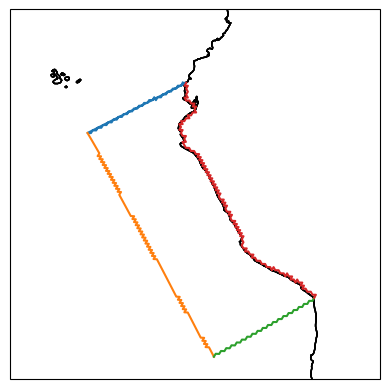

In [27]:
fig, ax = setup_plot_area(ds_IsD)
for section in reconstructed_sections:
    reconstructed_sections[section].plot(ax=ax, gridlines=False)

In [42]:
xr.open_dataset("/work/mh0033/NorthBoundarySection.nc")

<xarray.Dataset> Size: 3kB
Dimensions:           (step_in_path: 39, step_in_path_v: 41)
Coordinates:
  * step_in_path      (step_in_path) int64 312B 1 285 286 287 ... 320 321 322
    elon              (step_in_path) float64 312B ...
    elat              (step_in_path) float64 312B ...
    edge              (step_in_path) int32 156B ...
    vlon              (step_in_path_v) float64 328B ...
    vlat              (step_in_path_v) float64 328B ...
    vertex            (step_in_path_v) int32 164B ...
Dimensions without coordinates: step_in_path_v
Data variables:
    edge_path         (step_in_path) int32 156B ...
    vertex_path       (step_in_path_v) int32 164B ...
    path_orientation  (step_in_path) float64 312B ...
Attributes:
    date:     2026-01-21 11:14:08

In [41]:
for section in reconstructed_sections:
    reconstructed_sections[section].to_ispy_section(muxin_out_directory / f"{section.replace(' ', '')}.nc")

Output will be saved to /work/mh0033/NorthBoundarySection.nc
Output will be saved to /work/mh0033/WestBoundarySection.nc
Output will be saved to /work/mh0033/SouthBoundarySection.nc
Output will be saved to /work/mh0033/EastBoundarySection.nc


In the above we can see a funny straight line in the blue and green section. This is a bug that will be adressed in a future version. It arises from the repeating of the first vertex along the section at the end of the section. The edge paths remain unaffected though.

# For r2b7 grid

In [4]:
ocean_tgrid_path = Path("/home/m/m301254/pyicon_data/grids/r2b7_oce_r0005/r2b7_oce_r0005_tgrid.nc")
ocean_fxgrid_path = Path("/home/m/m301254/pyicon_data/grids/r2b7_oce_r0005/r2b7_oce_r0005_L72_fx.nc")

ds_tgrid = xr.open_dataset(ocean_tgrid_path)  # horizontal grid information
ds_fx = xr.open_dataset(ocean_fxgrid_path)  # Contains bathymetry etc.

# Put datasets into the iconspy format
ds_IsD = ispy.convert_tgrid_data(ds_tgrid)

ds_fx = ds_fx.rename(
    {
        "ncells": "cell",
        "ncells_2": "edge",
        "ncells_3": "vertex",
    }
)

In [5]:
def setup_plot_area(ds_IsD):
    Slat, Nlat = -25, 5
    Wlon, Elon = -95, -65

    edges_in_region = ds_IsD["edge"].where(
        (ds_IsD["elon"] > Wlon) * (ds_IsD["elon"] < Elon) * (ds_IsD["elat"] > Slat) * (ds_IsD["elat"] < Nlat)
        , drop=True).astype("int32")


    lons = ds_IsD["vlon"].sel(vertex=ds_IsD["edge_vertices"])
    lats = ds_IsD["vlat"].sel(vertex=ds_IsD["edge_vertices"])

    fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()})

    ax.set_xlim(Wlon, Elon)
    ax.set_ylim(Slat, Nlat)
    ax.set_aspect("equal")

    ax.coastlines()
    ax.grid(False)
    return fig, ax

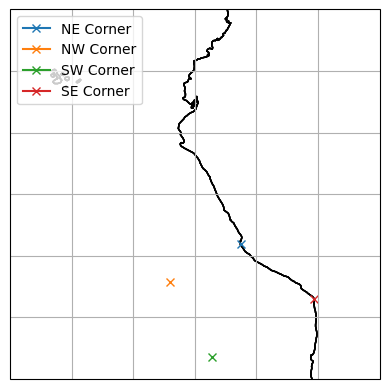

In [15]:
# Put in the approximate coordinates of the points we want
# Specify that we want the George Town point to be on the boundary

# Peru coast: general
# target_ne_corner = ispy.TargetStation("NE Corner", -80.72, -0.928, boundary=True)
# target_nw_corner = ispy.TargetStation("NW Corner", -88.794, -4.976, boundary=False)
# target_sw_corner = ispy.TargetStation("SW Corner", -78.592, -23.219, boundary=False)
# target_se_corner = ispy.TargetStation("SE Corner", -70.285, -18.491, boundary=True)

# # Peru coast: middle
# target_ne_corner = ispy.TargetStation("NE Corner", -81.152, -5.892, boundary=True)
# target_nw_corner = ispy.TargetStation("NW Corner", -86.624, -8.855, boundary=False)
# target_sw_corner = ispy.TargetStation("SW Corner", -81.987, -17.148, boundary=False)
# target_se_corner = ispy.TargetStation("SE Corner", -76.285, -14.042, boundary=True)

# # Peru coast: north
# target_ne_corner = ispy.TargetStation("NE Corner", -80.72, -0.928, boundary=True)
# target_nw_corner = ispy.TargetStation("NW Corner", -88.794, -4.976, boundary=False)
# target_se_corner = ispy.TargetStation("SE Corner", -81.152, -5.892, boundary=True)
# target_sw_corner = ispy.TargetStation("SW Corner", -86.624, -8.855, boundary=False)

# Peru coast: South
target_nw_corner = ispy.TargetStation("NW Corner", -81.987, -17.148, boundary=False)
target_ne_corner = ispy.TargetStation("NE Corner", -76.285, -14.042, boundary=True)
target_sw_corner = ispy.TargetStation("SW Corner", -78.592, -23.219, boundary=False)
target_se_corner = ispy.TargetStation("SE Corner", -70.285, -18.491, boundary=True)

# Visualise the points
fig, ax = setup_plot_area(ds_IsD)
target_ne_corner.plot(ax=ax, gridlines=False)
target_nw_corner.plot(ax=ax, gridlines=False)
target_sw_corner.plot(ax=ax, gridlines=False)
target_se_corner.plot(ax=ax, gridlines=False)
gl = ax.gridlines()
# gl.xlines, gl.ylines = False, False
# ax.grid(visible=False)
ax.legend(loc=2)

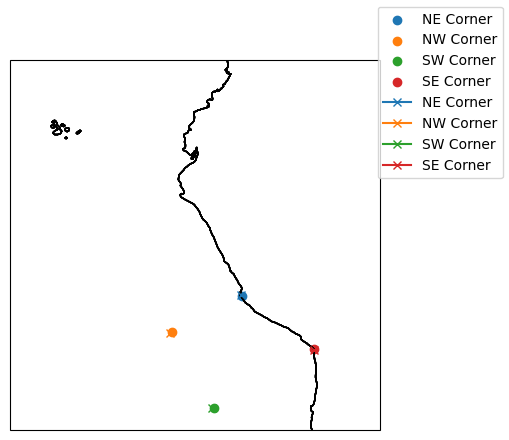

In [16]:
# Convert the target stations to model stations
model_ne_corner = target_ne_corner.to_model_station(ds_IsD)
model_nw_corner = target_nw_corner.to_model_station(ds_IsD)
model_sw_corner = target_sw_corner.to_model_station(ds_IsD)
model_se_corner = target_se_corner.to_model_station(ds_IsD)

fig, ax = setup_plot_area(ds_IsD)

# Plot the model stations (circles)
model_ne_corner.plot(ax=ax, gridlines=False)
model_nw_corner.plot(ax=ax, gridlines=False)
model_sw_corner.plot(ax=ax, gridlines=False)
model_se_corner.plot(ax=ax, gridlines=False)

# Compare with the target station (crosses)
target_ne_corner.plot(ax=ax, gridlines=False)
target_nw_corner.plot(ax=ax, gridlines=False)
target_sw_corner.plot(ax=ax, gridlines=False)
target_se_corner.plot(ax=ax, gridlines=False)

fig.legend()

In [17]:
print(model_ne_corner.model_lon, model_ne_corner.model_lat)
print(model_nw_corner.model_lon, model_nw_corner.model_lat)
print(model_sw_corner.model_lon, model_sw_corner.model_lat)
print(model_se_corner.model_lon, model_se_corner.model_lat)


-76.1918149062049 -14.143596192538995
-81.88161640099453 -17.065344487343168
-78.45085899756207 -23.193188246937353
-70.30938544006708 -18.409944603757268


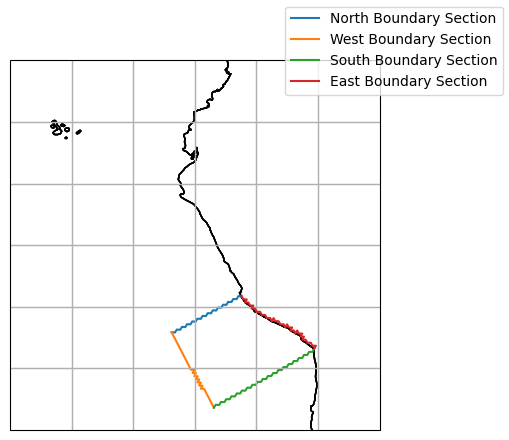

In [22]:
north_boundary_section = ispy.Section(
    "North Boundary Section",
    model_ne_corner,
    model_nw_corner,
    ds_IsD,
    section_type="great circle"
)

west_boundary_section = ispy.Section(
    "West Boundary Section",
    model_nw_corner,
    model_sw_corner,
    ds_IsD,
    section_type="great circle"
)

south_boundary_section = ispy.Section(
    "South Boundary Section",
    model_sw_corner,
    model_se_corner,
    ds_IsD,
    section_type="great circle"
)

east_boundary_section = ispy.LandSection(
    "East Boundary Section",
    model_se_corner,
    model_ne_corner,
    ds_IsD,
    section_type="shortest"
)

fig, ax = setup_plot_area(ds_IsD)
north_boundary_section.plot(ax=ax)
west_boundary_section.plot(ax=ax)
south_boundary_section.plot(ax=ax)
east_boundary_section.plot(ax=ax)

fig.legend()

# cax = ax.tripcolor(
#     ds_IsD["clon"],
#     ds_IsD["clat"],
#     ds_fx["column_thick_c"],
#     vmin=0,
#     vmax=5000,
#     cmap=cmo.deep,
# )

# fig.colorbar(cax, ax=ax, label="Column thickness")

In [23]:
north_boundary_section.set_pyic_orientation_along_path(ds_IsD)
west_boundary_section.set_pyic_orientation_along_path(ds_IsD)
south_boundary_section.set_pyic_orientation_along_path(ds_IsD)
east_boundary_section.set_pyic_orientation_along_path(ds_IsD)

In [24]:
peru_coastal_region = ispy.Region("Peru Coastal Region", [north_boundary_section, west_boundary_section, south_boundary_section, east_boundary_section], ds_IsD)
# peru_coastal_region

/home/m/m301254/.conda/envs/ispy_py311/lib/python3.11/site-packages/iconspy/utils.py:122: UserWarning: rename 'step_in_path_v' to 'step_in_path' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  edge_path_xr = edge_path_xr.rename(step_in_path_v="step_in_path")
/home/m/m301254/.conda/envs/ispy_py311/lib/python3.11/site-packages/iconspy/utils.py:33: UserWarning: rename 'step_in_path_v' to 'step_in_path' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  vertex_path = vertex_path.rename(step_in_path_v="step_in_path")


In [25]:
muxin_out_directory = Path("/work/mh0033/m301254/proj_surfwave/masks/secs_to_mask")
peru_coastal_region.to_ispy_section(muxin_out_directory / "pc_south_sections_masks_oce_r2b7.nc") 

Output will be saved to /work/mh0033/m301254/proj_surfwave/masks/secs_to_mask/pc_south_sections_masks_oce_r2b7.nc


<xarray.Dataset> Size: 47kB
Dimensions:           (step_in_path: 136, step_in_path_v: 137, cell: 1598)
Coordinates:
  * step_in_path      (step_in_path) int64 1kB 1 2 3 4 5 ... 132 133 134 135 136
  * cell              (cell) int32 6kB 508241 508242 508243 ... 527762 527763
    elon              (step_in_path) float64 1kB -76.33 -76.12 ... -76.74 -76.54
    elat              (step_in_path) float64 1kB -14.14 -14.27 ... -14.37 -14.26
    edge              (step_in_path) int32 544B 792121 791919 ... 792127 792116
    vlon              (step_in_path_v) float64 1kB -76.47 -76.19 ... -76.47
    vlat              (step_in_path_v) float64 1kB -14.14 -14.14 ... -14.14
    vertex            (step_in_path_v) int32 548B 268558 268471 ... 268558
    clon              (cell) float64 13kB -81.46 -81.33 -81.47 ... -73.34 -73.48
    clat              (cell) float64 13kB -17.01 -16.94 -17.18 ... -17.74 -17.99
Dimensions without coordinates: step_in_path_v
Data variables:
    edge_path         (step_in_path) int32 544B 792121 791919 ... 792127 792116
    vertex_path       (step_in_path_v) int32 548B 268558 268471 ... 268558
    path_orientation  (step_in_path) float64 1kB 1.0 -1.0 -1.0 ... -1.0 1.0 1.0
    contained_cells   (cell) int32 6kB 508241 508242 508243 ... 527762 527763
Attributes:
    date:     2026-01-22 16:12:08

In [26]:
reconstructed_sections = peru_coastal_region.extract_sections_from_region(ds_IsD)
for section in reconstructed_sections:
    reconstructed_sections[section].to_ispy_section(muxin_out_directory / f"pc_south_sections_{section.replace(' ', '')}_oce_r2b7.nc")

Output will be saved to /work/mh0033/m301254/proj_surfwave/masks/secs_to_mask/pc_south_sections_NorthBoundarySection_oce_r2b7.nc
Output will be saved to /work/mh0033/m301254/proj_surfwave/masks/secs_to_mask/pc_south_sections_WestBoundarySection_oce_r2b7.nc
Output will be saved to /work/mh0033/m301254/proj_surfwave/masks/secs_to_mask/pc_south_sections_SouthBoundarySection_oce_r2b7.nc
Output will be saved to /work/mh0033/m301254/proj_surfwave/masks/secs_to_mask/pc_south_sections_EastBoundarySection_oce_r2b7.nc


# For r2b9 grid

In [3]:
ocean_tgrid_path = Path("/home/m/m301254/pyicon_data/grids/r2b9_oce_r0004/r2b9_oce_r0004_tgrid.nc")
ocean_fxgrid_path = Path("/home/m/m301254/pyicon_data/grids/r2b9_oce_r0004/r2b9_oce_r0004_L72.nc")

ds_tgrid = xr.open_dataset(ocean_tgrid_path)  # horizontal grid information
ds_fx = xr.open_dataset(ocean_fxgrid_path)  # Contains bathymetry etc.

# Put datasets into the iconspy format
ds_IsD = ispy.convert_tgrid_data(ds_tgrid)

ds_fx = ds_fx.rename(
    {
        "ncells": "cell",
        "ncells_2": "edge",
        "ncells_3": "vertex",
    }
)

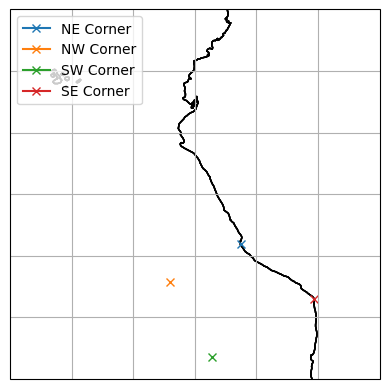

In [51]:
# Put in the approximate coordinates of the points we want
# Specify that we want the George Town point to be on the boundary

# Peru coast: general
# target_ne_corner = ispy.TargetStation("NE Corner", -80.72, -0.928, boundary=True)
# target_nw_corner = ispy.TargetStation("NW Corner", -88.794, -4.976, boundary=False)
# target_sw_corner = ispy.TargetStation("SW Corner", -78.592, -23.219, boundary=False)
# target_se_corner = ispy.TargetStation("SE Corner", -70.285, -18.491, boundary=True)

# # Peru coast: middle
# target_ne_corner = ispy.TargetStation("NE Corner", -81.152, -5.892, boundary=True)
# target_nw_corner = ispy.TargetStation("NW Corner", -86.624, -8.855, boundary=False)
# target_sw_corner = ispy.TargetStation("SW Corner", -81.987, -17.148, boundary=False)
# target_se_corner = ispy.TargetStation("SE Corner", -76.285, -14.042, boundary=True)

# # Peru coast: north
# target_ne_corner = ispy.TargetStation("NE Corner", -80.72, -0.928, boundary=True)
# target_nw_corner = ispy.TargetStation("NW Corner", -88.794, -4.976, boundary=False)
# target_se_corner = ispy.TargetStation("SE Corner", -81.152, -5.892, boundary=True)
# target_sw_corner = ispy.TargetStation("SW Corner", -86.624, -8.855, boundary=False)

# # Peru coast: South
target_nw_corner = ispy.TargetStation("NW Corner", -81.987, -17.148, boundary=False)
target_ne_corner = ispy.TargetStation("NE Corner", -76.285, -14.042, boundary=True)
target_sw_corner = ispy.TargetStation("SW Corner", -78.592, -23.219, boundary=False)
target_se_corner = ispy.TargetStation("SE Corner", -70.285, -18.491, boundary=True)

# Visualise the points
fig, ax = setup_plot_area(ds_IsD)
target_ne_corner.plot(ax=ax, gridlines=False)
target_nw_corner.plot(ax=ax, gridlines=False)
target_sw_corner.plot(ax=ax, gridlines=False)
target_se_corner.plot(ax=ax, gridlines=False)
gl = ax.gridlines()
# gl.xlines, gl.ylines = False, False
# ax.grid(visible=False)
ax.legend(loc=2)

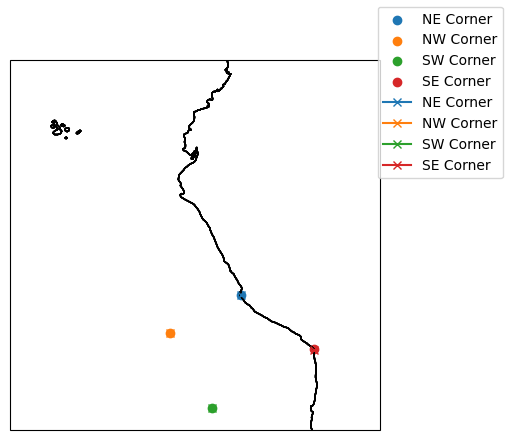

In [52]:
# Convert the target stations to model stations
model_ne_corner = target_ne_corner.to_model_station(ds_IsD)
model_nw_corner = target_nw_corner.to_model_station(ds_IsD)
model_sw_corner = target_sw_corner.to_model_station(ds_IsD)
model_se_corner = target_se_corner.to_model_station(ds_IsD)

fig, ax = setup_plot_area(ds_IsD)

# Plot the model stations (circles)
model_ne_corner.plot(ax=ax, gridlines=False)
model_nw_corner.plot(ax=ax, gridlines=False)
model_sw_corner.plot(ax=ax, gridlines=False)
model_se_corner.plot(ax=ax, gridlines=False)

# Compare with the target station (crosses)
target_ne_corner.plot(ax=ax, gridlines=False)
target_nw_corner.plot(ax=ax, gridlines=False)
target_sw_corner.plot(ax=ax, gridlines=False)
target_se_corner.plot(ax=ax, gridlines=False)

fig.legend()

create the boundary section based on the corner information

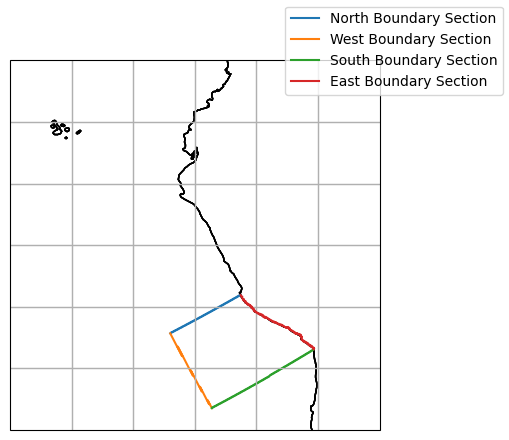

In [53]:
north_boundary_section = ispy.Section(
    "North Boundary Section",
    model_ne_corner,
    model_nw_corner,
    ds_IsD,
    section_type="great circle"
)

west_boundary_section = ispy.Section(
    "West Boundary Section",
    model_nw_corner,
    model_sw_corner,
    ds_IsD,
    section_type="great circle"
)

south_boundary_section = ispy.Section(
    "South Boundary Section",
    model_sw_corner,
    model_se_corner,
    ds_IsD,
    section_type="great circle"
)

east_boundary_section = ispy.LandSection(
    "East Boundary Section",
    model_se_corner,
    model_ne_corner,
    ds_IsD,
    section_type="shortest"
)

fig, ax = setup_plot_area(ds_IsD)
north_boundary_section.plot(ax=ax)
west_boundary_section.plot(ax=ax)
south_boundary_section.plot(ax=ax)
east_boundary_section.plot(ax=ax)

fig.legend()

# cax = ax.tripcolor(
#     ds_IsD["clon"],
#     ds_IsD["clat"],
#     ds_fx["column_thick_c"],
#     vmin=0,
#     vmax=5000,
#     cmap=cmo.deep,
# )

# fig.colorbar(cax, ax=ax, label="Column thickness")

getting orientation file from the function `set_pyic_orientation_along_path`

In [54]:
north_boundary_section.set_pyic_orientation_along_path(ds_IsD)
west_boundary_section.set_pyic_orientation_along_path(ds_IsD)
south_boundary_section.set_pyic_orientation_along_path(ds_IsD)
east_boundary_section.set_pyic_orientation_along_path(ds_IsD)

connect sections to from a region

In [55]:
peru_coastal_region = ispy.Region("Peru Coastal Region", [north_boundary_section, west_boundary_section, south_boundary_section, east_boundary_section], ds_IsD)
# peru_coastal_region

/home/m/m301254/.conda/envs/ispy_py311/lib/python3.11/site-packages/iconspy/utils.py:122: UserWarning: rename 'step_in_path_v' to 'step_in_path' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  edge_path_xr = edge_path_xr.rename(step_in_path_v="step_in_path")
/home/m/m301254/.conda/envs/ispy_py311/lib/python3.11/site-packages/iconspy/utils.py:33: UserWarning: rename 'step_in_path_v' to 'step_in_path' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  vertex_path = vertex_path.rename(step_in_path_v="step_in_path")


In [41]:
# fig, ax = setup_plot_area(ds_IsD)
# peru_coastal_region.plot(ax=ax, gridlines=False)

save it as intermediate files in the sections

In [56]:
muxin_out_directory = Path("/work/mh0033/m301254/proj_eddy_upwelling/masks/secs_to_mask")
peru_coastal_region.to_ispy_section(muxin_out_directory / "pc_south_sections_masks_oce_r2b9.nc")  # set dryrun=False to actually save the file.

Output will be saved to /work/mh0033/m301254/proj_eddy_upwelling/masks/secs_to_mask/pc_south_sections_masks_oce_r2b9.nc


<xarray.Dataset> Size: 657kB
Dimensions:           (step_in_path: 562, step_in_path_v: 563, cell: 25860)
Coordinates:
  * step_in_path      (step_in_path) int64 4kB 1 2 3 4 5 ... 558 559 560 561 562
  * cell              (cell) int32 103kB 8072084 8072090 ... 8382865 8382866
    elon              (step_in_path) float64 4kB -76.31 -76.26 ... -76.42 -76.36
    elat              (step_in_path) float64 4kB -14.05 -14.08 ... -14.1 -14.07
    edge              (step_in_path) int32 2kB 12509140 12509151 ... 12509152
    vlon              (step_in_path_v) float64 5kB -76.35 -76.28 ... -76.35
    vlat              (step_in_path_v) float64 5kB -14.04 -14.05 ... -14.04
    vertex            (step_in_path_v) int32 2kB 4194646 4194645 ... 4194646
    clon              (cell) float64 207kB -81.96 -81.92 ... -73.58 -73.51
    clat              (cell) float64 207kB -17.14 -17.12 ... -17.89 -17.89
Dimensions without coordinates: step_in_path_v
Data variables:
    edge_path         (step_in_path) int32 2kB 12509140 12509151 ... 12509152
    vertex_path       (step_in_path_v) int32 2kB 4194646 4194645 ... 4194646
    path_orientation  (step_in_path) float64 4kB -1.0 -1.0 1.0 ... 1.0 1.0 -1.0
    contained_cells   (cell) int32 103kB 8072084 8072090 ... 8382865 8382866
Attributes:
    date:     2026-01-22 16:48:37

In [57]:
reconstructed_sections = peru_coastal_region.extract_sections_from_region(ds_IsD)
for section in reconstructed_sections:
    reconstructed_sections[section].to_ispy_section(muxin_out_directory / f"pc_south_sections_{section.replace(' ', '')}_oce_r2b9.nc")

Output will be saved to /work/mh0033/m301254/proj_eddy_upwelling/masks/secs_to_mask/pc_south_sections_NorthBoundarySection_oce_r2b9.nc
Output will be saved to /work/mh0033/m301254/proj_eddy_upwelling/masks/secs_to_mask/pc_south_sections_WestBoundarySection_oce_r2b9.nc
Output will be saved to /work/mh0033/m301254/proj_eddy_upwelling/masks/secs_to_mask/pc_south_sections_SouthBoundarySection_oce_r2b9.nc
Output will be saved to /work/mh0033/m301254/proj_eddy_upwelling/masks/secs_to_mask/pc_south_sections_EastBoundarySection_oce_r2b9.nc


## Cross-sections

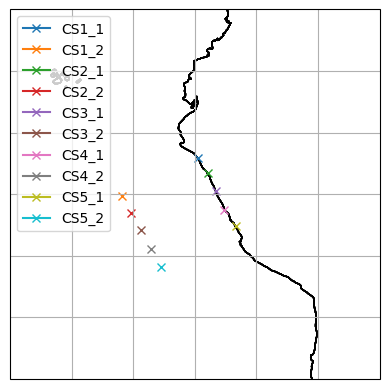

In [5]:
# Put in the approximate coordinates of the points we want
# Specify that we want the George Town point to be on the boundary

# 1st cross-section 
CS1_1 = ispy.TargetStation("CS1_1", -79.769, -7.027, boundary=True)
CS1_2 = ispy.TargetStation("CS1_2", -85.940, -10.132, boundary=False)
# 2nd cross-section 
CS2_1 = ispy.TargetStation("CS2_1", -78.955, -8.286, boundary=True)
CS2_2 = ispy.TargetStation("CS2_2", -85.193, -11.511, boundary=False)
# 3rd cross-section 
CS3_1 = ispy.TargetStation("CS3_1", -78.278, -9.746, boundary=True)
CS3_2 = ispy.TargetStation("CS3_2", -84.405, -12.943, boundary=False)
# 4th cross-section 
CS4_1 = ispy.TargetStation("CS4_1", -77.644, -11.307, boundary=True)
CS4_2 = ispy.TargetStation("CS4_2", -83.579, -14.431, boundary=False)
# 5th cross-section 
CS5_1 = ispy.TargetStation("CS5_1", -76.688, -12.609, boundary=True)
CS5_2 = ispy.TargetStation("CS5_2", -82.766, -15.882, boundary=False)

# Visualise the points
fig, ax = setup_plot_area(ds_IsD)
CS1_1.plot(ax=ax, gridlines=False)
CS1_2.plot(ax=ax, gridlines=False)
CS2_1.plot(ax=ax, gridlines=False)
CS2_2.plot(ax=ax, gridlines=False)
CS3_1.plot(ax=ax, gridlines=False)
CS3_2.plot(ax=ax, gridlines=False)
CS4_1.plot(ax=ax, gridlines=False)
CS4_2.plot(ax=ax, gridlines=False)
CS5_1.plot(ax=ax, gridlines=False)
CS5_2.plot(ax=ax, gridlines=False)
# target_sw_corner.plot(ax=ax, gridlines=False)
# target_se_corner.plot(ax=ax, gridlines=False)
gl = ax.gridlines()
# gl.xlines, gl.ylines = False, False
# ax.grid(visible=False)
ax.legend(loc=2)

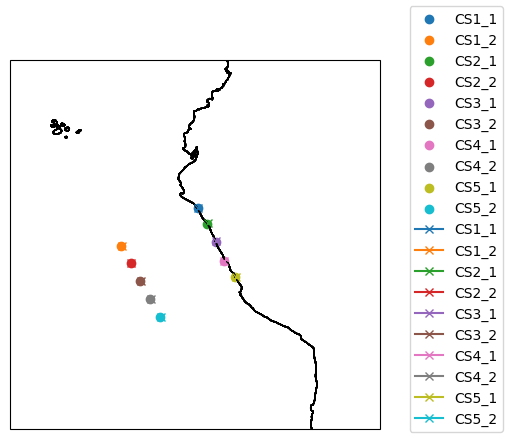

In [6]:
# Convert the target stations to model stations
model_CS1_1 = CS1_1.to_model_station(ds_IsD)
model_CS1_2 = CS1_2.to_model_station(ds_IsD)

model_CS2_1 = CS2_1.to_model_station(ds_IsD)
model_CS2_2 = CS2_2.to_model_station(ds_IsD)

model_CS3_1 = CS3_1.to_model_station(ds_IsD)
model_CS3_2 = CS3_2.to_model_station(ds_IsD)

model_CS4_1 = CS4_1.to_model_station(ds_IsD)
model_CS4_2 = CS4_2.to_model_station(ds_IsD)

model_CS5_1 = CS5_1.to_model_station(ds_IsD)
model_CS5_2 = CS5_2.to_model_station(ds_IsD)


fig, ax = setup_plot_area(ds_IsD)

# Plot the model stations (circles)
model_CS1_1.plot(ax=ax, gridlines=False)
model_CS1_2.plot(ax=ax, gridlines=False)
model_CS2_1.plot(ax=ax, gridlines=False)
model_CS2_2.plot(ax=ax, gridlines=False)
model_CS3_1.plot(ax=ax, gridlines=False)
model_CS3_2.plot(ax=ax, gridlines=False)
model_CS4_1.plot(ax=ax, gridlines=False)
model_CS4_2.plot(ax=ax, gridlines=False)
model_CS5_1.plot(ax=ax, gridlines=False)
model_CS5_2.plot(ax=ax, gridlines=False)

# Compare with the target station (crosses)
CS1_1.plot(ax=ax, gridlines=False)
CS1_2.plot(ax=ax, gridlines=False)
CS2_1.plot(ax=ax, gridlines=False)
CS2_2.plot(ax=ax, gridlines=False)
CS3_1.plot(ax=ax, gridlines=False)
CS3_2.plot(ax=ax, gridlines=False)
CS4_1.plot(ax=ax, gridlines=False)
CS4_2.plot(ax=ax, gridlines=False)
CS5_1.plot(ax=ax, gridlines=False)
CS5_2.plot(ax=ax, gridlines=False)

fig.legend()

In [8]:
# check the lon/lat for model station for the sections
pairs = [("CS1",  model_CS1_1, model_CS1_2),
         ("CS2",  model_CS2_1, model_CS2_2),
         ("CS3",  model_CS3_1, model_CS3_2),
         ("CS4",  model_CS4_1, model_CS4_2),
         ("CS5",  model_CS5_1, model_CS5_2),]

for sec, onshore, offshore in pairs:
    print(sec)
    print(f"onshore point (lon, lat): ({onshore.model_lon}, {onshore.model_lat})")
    print(f"offshore point (lon, lat): ({offshore.model_lon}, {offshore.model_lat})")


CS1
onshore point (lon, lat): (-79.75512144141588, -7.021806377672825)
offshore point (lon, lat): (-85.95389020750532, -10.12060537018413)
CS2
onshore point (lon, lat): (-78.98192745104265, -8.307928438450526)
offshore point (lon, lat): (-85.17853815301227, -11.528303331614662)
CS3
onshore point (lon, lat): (-78.31370327511752, -9.779326348121353)
offshore point (lon, lat): (-84.40927619374119, -12.948541314245812)
CS4
onshore point (lon, lat): (-77.61337110810675, -11.319061515147252)
offshore point (lon, lat): (-83.6125601869064, -14.442576935326455)
CS5
onshore point (lon, lat): (-76.70718819670485, -12.625979489344038)
offshore point (lon, lat): (-82.78540916611692, -15.889067595180334)


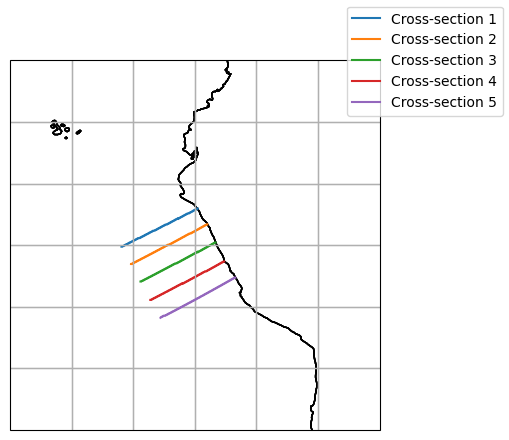

In [11]:
section1 = ispy.Section(
    "Cross-section 1",
    model_CS1_1,
    model_CS1_2,
    ds_IsD,
    section_type="great circle"
)

section2 = ispy.Section(
    "Cross-section 2",
    model_CS2_1,
    model_CS2_2,
    ds_IsD,
    section_type="great circle"
)

section3 = ispy.Section(
    "Cross-section 3",
    model_CS3_1,
    model_CS3_2,
    ds_IsD,
    section_type="great circle"
)

section4 = ispy.Section(
    "Cross-section 4",
    model_CS4_1,
    model_CS4_2,
    ds_IsD,
    section_type="great circle"
)

section5 = ispy.Section(
    "Cross-section 5",
    model_CS5_1,
    model_CS5_2,
    ds_IsD,
    section_type="great circle"
)

fig, ax = setup_plot_area(ds_IsD)
section1.plot(ax=ax)
section2.plot(ax=ax)
section3.plot(ax=ax)
section4.plot(ax=ax)
section5.plot(ax=ax)

fig.legend()

In [12]:
section1.set_pyic_orientation_along_path(ds_IsD)
section2.set_pyic_orientation_along_path(ds_IsD)
section3.set_pyic_orientation_along_path(ds_IsD)
section4.set_pyic_orientation_along_path(ds_IsD)
section5.set_pyic_orientation_along_path(ds_IsD)

In [16]:
# save the sections
muxin_out_directory = Path("/work/mh0033/m301254/proj_eddy_upwelling/masks/secs_to_mask/individual_sec")
section1.to_ispy_section(muxin_out_directory / "section1_r2b9.nc")
section2.to_ispy_section(muxin_out_directory / "section2_r2b9.nc")
section3.to_ispy_section(muxin_out_directory / "section3_r2b9.nc")
section4.to_ispy_section(muxin_out_directory / "section4_r2b9.nc")  
section5.to_ispy_section(muxin_out_directory / "section5_r2b9.nc")  

Output will be saved to /work/mh0033/m301254/proj_eddy_upwelling/masks/secs_to_mask/individual_sec/section1_r2b9.nc
Output will be saved to /work/mh0033/m301254/proj_eddy_upwelling/masks/secs_to_mask/individual_sec/section2_r2b9.nc
Output will be saved to /work/mh0033/m301254/proj_eddy_upwelling/masks/secs_to_mask/individual_sec/section3_r2b9.nc
Output will be saved to /work/mh0033/m301254/proj_eddy_upwelling/masks/secs_to_mask/individual_sec/section4_r2b9.nc
Output will be saved to /work/mh0033/m301254/proj_eddy_upwelling/masks/secs_to_mask/individual_sec/section5_r2b9.nc


<xarray.Dataset> Size: 7kB
Dimensions:           (step_in_path: 117, step_in_path_v: 118)
Coordinates:
  * step_in_path      (step_in_path) int32 468B 4193666 4193742 ... 4074446
  * step_in_path_v    (step_in_path_v) int32 472B 4193656 4193666 ... 4074446
    elon              (step_in_path) float64 936B -76.74 -76.79 ... -82.77
    elat              (step_in_path) float64 936B -12.63 -12.65 ... -15.86
    edge              (step_in_path) int32 468B 12506414 12506627 ... 12148990
    vlon              (step_in_path_v) float64 944B -76.71 -76.78 ... -82.79
    vlat              (step_in_path_v) float64 944B -12.63 -12.62 ... -15.89
Data variables:
    edge_path         (step_in_path) int32 468B 12506414 12506627 ... 12148990
    vertex_path       (step_in_path_v) int32 472B 4193656 4193666 ... 4074446
    path_orientation  (step_in_path) float64 936B 1.0 -1.0 -1.0 ... -1.0 1.0 1.0
Attributes:
    date:     2026-01-23 16:58:38